In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# 导入数据
data = pd.read_csv('housing.csv')
print(data.info())  # 查看数据类型，是否有缺失值
print(data.describe())  # 统计信息

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952

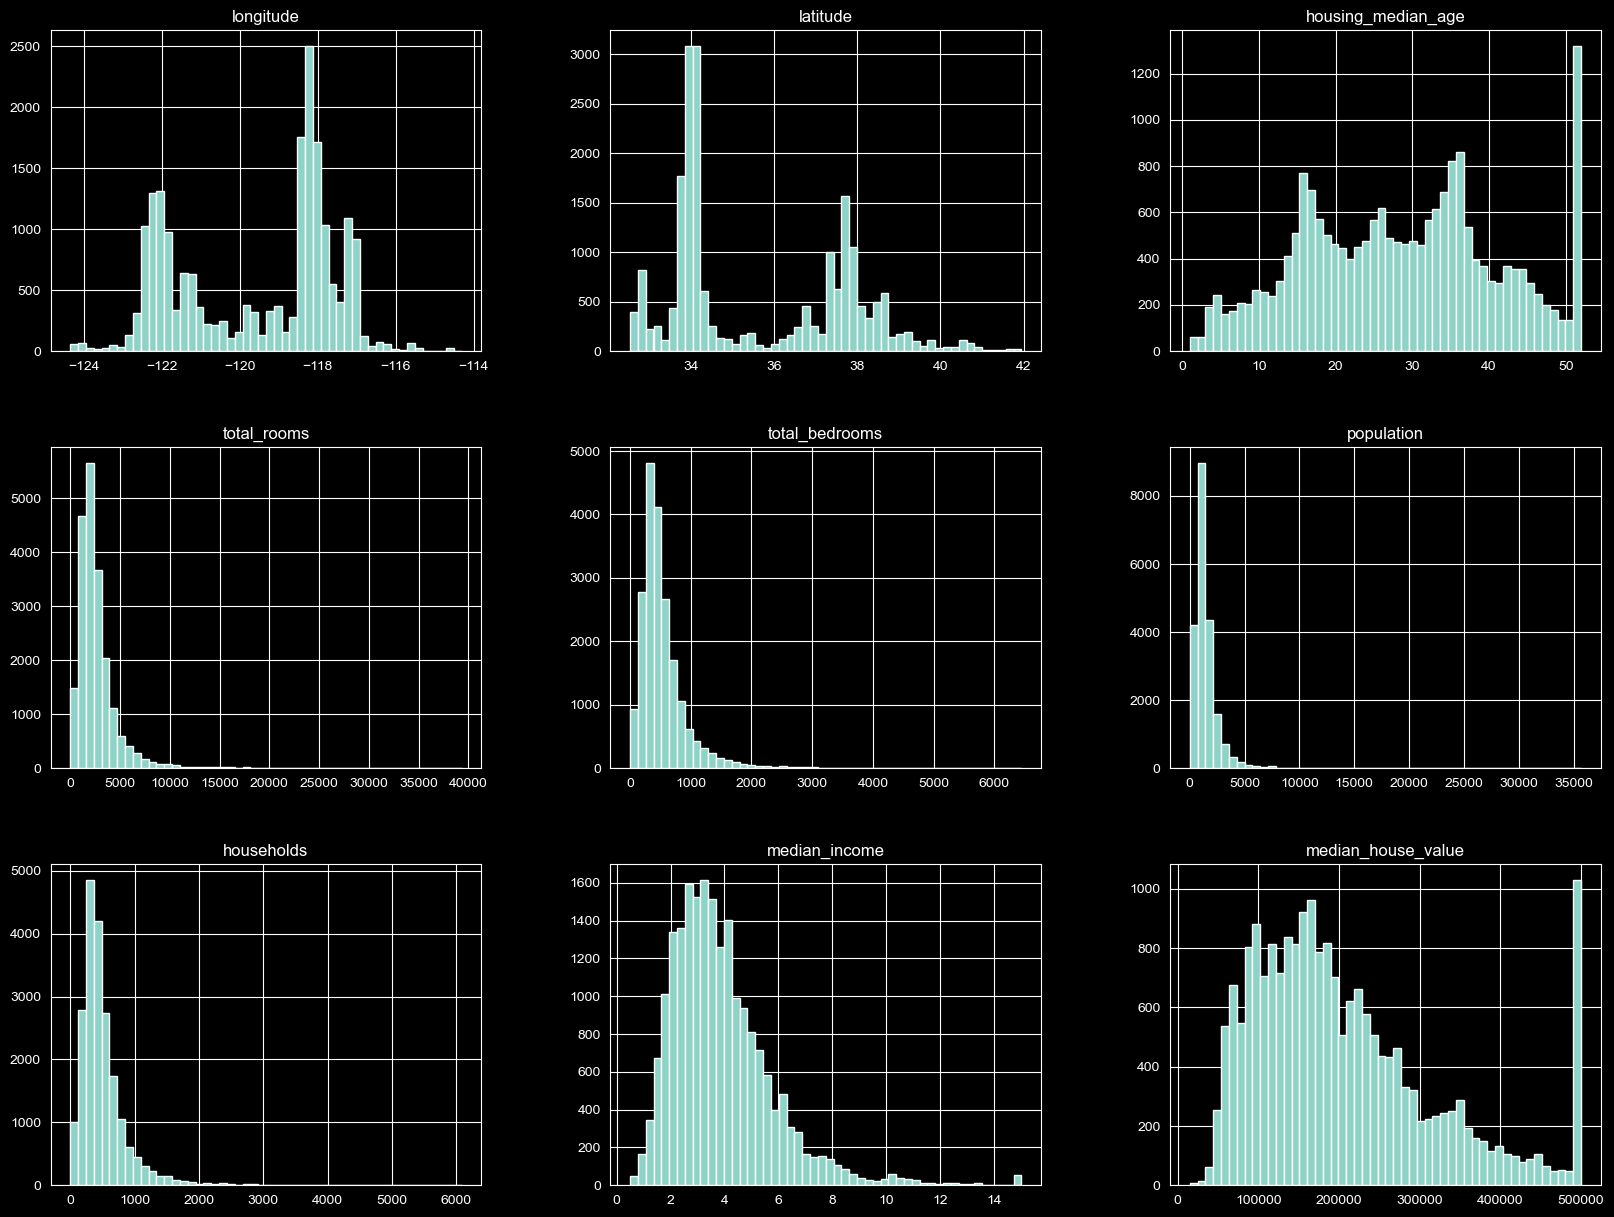

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [15]:
# 观察分布
data.hist(bins=50, figsize=(20,15))
plt.show()
# 预处理：检查缺失值
print(data.isnull().sum())
# 填充缺失值
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())
# 处理分类特征
data = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True)
# 特征和目标
X = data.drop('median_house_value', axis=1)  # 目标是median_house_value
y = data['median_house_value']
# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# 标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Mean Squared Error: 4733529273.092552


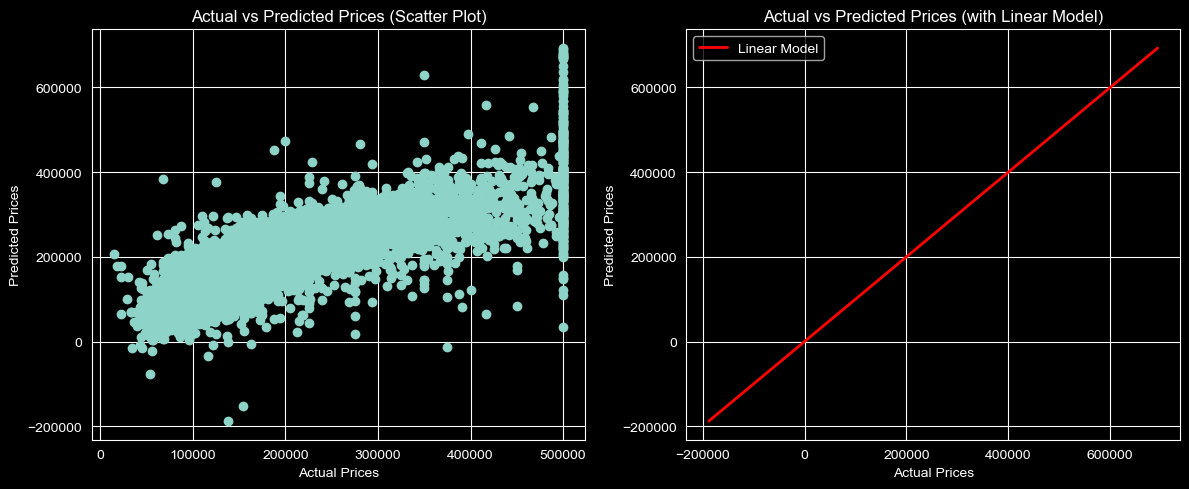

In [22]:
# 线性回归模型
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 预测
y_pred = model.predict(X_test_scaled)

# 评估
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
# 可视化1：原始散点图（实际值 vs 预测值）
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Scatter Plot)')

# 可视化2：散点图 + 线性模型直线
plt.subplot(1, 2, 2)
# 绘制理想的线性模型直线 (y = x)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r-', linewidth=2, label='Linear Model')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (with Linear Model)')
plt.legend()

plt.tight_layout()
plt.show()